<a href="https://colab.research.google.com/github/officialaryansingh/machine_learning/blob/main/ML%20projects/Project_08_Gold_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# importing the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Data Collection and Processing

In [14]:
# loading the csv data to Pandas DataFrame
gold_data = pd.read_csv('/content/gld_price_data.csv')

In [15]:
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [16]:
# shape of the dataset
gold_data.shape

(2290, 6)

In [17]:
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [18]:
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [19]:
# cheacking the number of missing values
gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [20]:
# getting the statistical measures of the data
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Correlation:

1. Positive Correlation

2. Negative Correlation

In [21]:
correlation = gold_data.corr(numeric_only=True)

<Axes: >

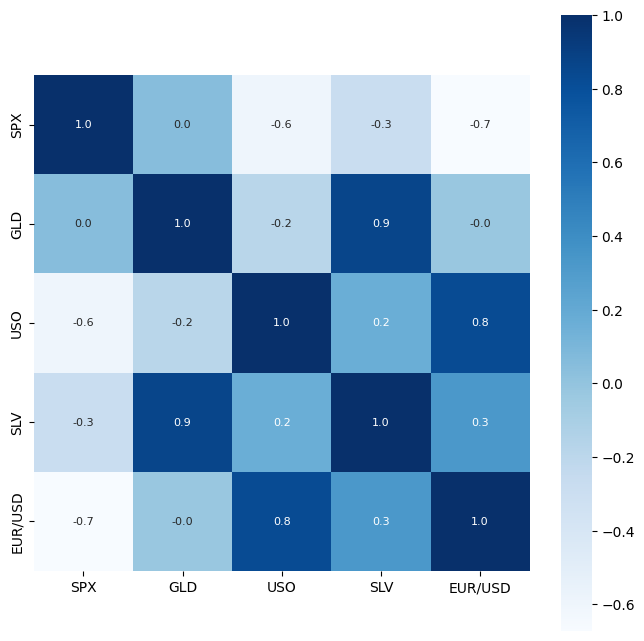

In [22]:
# contructing the heat map to understand the correlation
plt.figure(figsize = (8,8))
sns.heatmap(correlation,cbar = True, square = True, fmt = '.1f' ,annot = True, annot_kws = {'size':8},cmap = 'Blues')

In [23]:
# correlation values of GLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


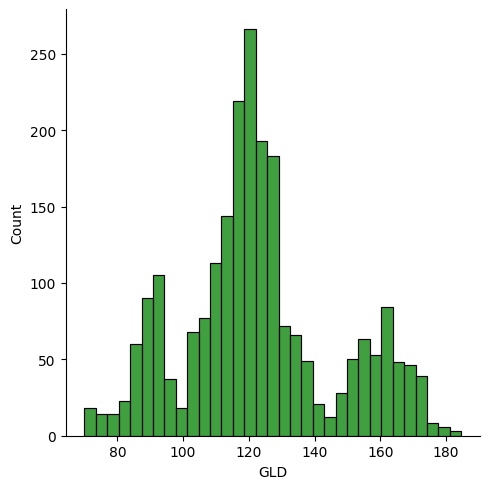

In [24]:
# checking the distribution of the GLD Price
sns.displot(gold_data['GLD'],color = 'green')

Spliting the Features and Target

In [26]:
X = gold_data.drop(['Date','GLD'],axis = 1)
Y = gold_data['GLD']

In [27]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [28]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


Splitting into Training and Testing Data

In [29]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 2)

Model training: Random Forest Regressor

In [30]:
regressor = RandomForestRegressor(n_estimators = 100)

In [31]:
# training the model
regressor.fit(X_train,Y_train)

RandomForestRegressor()

Model Evaluation

In [32]:
# prediction on the Test data
test_data_prediction = regressor.predict(X_test)

In [33]:
print(test_data_prediction)

[168.52199908  82.11689984 115.84410011 127.54310064 120.77980143
 154.66949736 150.55119793 126.07410026 117.48429874 125.98030091
 116.7255011  171.63270094 141.778498   167.79629935 115.17180043
 117.80140073 136.62070389 170.00580056 159.88760365 159.52159946
 155.17789984 125.26460024 176.2173005  156.92000383 125.22290031
  93.92480001  77.85070003 120.53499995 119.13519969 167.44700008
  88.26120027 125.27739999  91.10660078 117.68800003 121.03789917
 136.39830042 115.57980148 115.55290077 147.12879935 107.61850125
 104.44560233  87.11349784 126.50570036 117.94089965 155.0326987
 119.71019999 108.40749984 108.07409821  93.12340037 127.13539787
  74.91040037 113.67999892 121.48699994 111.30309879 118.842899
 121.03459892 158.82060082 166.4159016  147.13359693  85.86759861
  94.25970036  86.76019936  90.53140039 119.03710078 126.44650109
 127.55480013 168.66700019 122.27919945 117.17519906  98.9044002
 167.81870043 143.22979853 131.5341026  121.22520214 120.70529935
 119.58050052 

In [34]:
# squared error
error_score = metrics.r2_score(Y_test,test_data_prediction)
print("R squared error",error_score)

R squared error 0.9893742245611433


Compare the actual values and presicted values in a Plot

In [35]:
Y_test = list(Y_test)

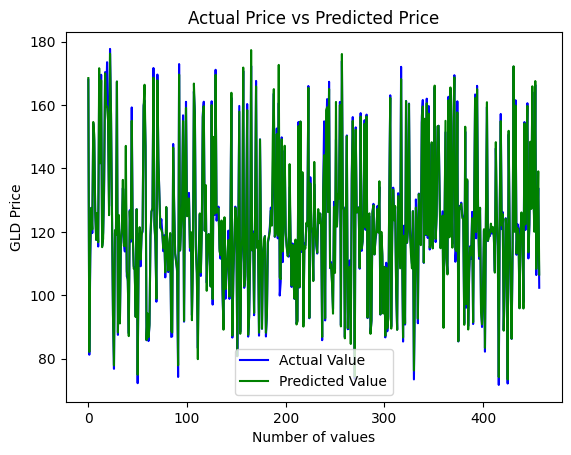

In [36]:
plt.plot(Y_test,color = 'blue', label = 'Actual Value')
plt.plot(test_data_prediction,color = 'green', label = 'Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()